# Información inicial

- Universidad de Buenos Aires
- Especialización en Inteligencia Artificial
- Probabilidad y Estadística para la Inteligencia Artificial
- *Docente:* Camilo Argoty
- *Alumno:* Rodrigo Hernández Código: a2526
- *Fecha:* 08/06/26

# Punto 1

**(3 puntos)** Una variable aleatoria discreta $X$ puede tomar los valores $0$, $1$, $2$ y $3$. Las probabilidades para cada valor posible están dadas por la siguiente tabla:

| $X$ | $0$ | $1$ | $2$ | $3$ |
|:---:|:---:|:---:|:---:|:---:|
| $p$ | $\dfrac{3\theta}{3}$ | $\dfrac{6\theta}{3}$ | $\dfrac{1-3\theta}{3}$ | $\dfrac{2(1-3\theta)}{3}$ |

Si experimentalmente se obtienen los siguientes datos:

$$(2,\, 2,\, 0,\, 2,\, 0,\, 2,\, 3,\, 2,\, 3,\, 1),$$

determine el valor de $\theta$ usando el método de máxima verosimilitud.

## Respuesta al punto 1

> **Respuesta:** $\hat\theta = \dfrac{1}{10} = 0.1$.

### Planteo: la función de masa y su dominio

La variable $X$ es discreta y su función de masa de probabilidad (f.m.p.), simplificando las fracciones de la tabla, es:

$$
p(0;\theta)=\frac{3\theta}{3}=\theta,\qquad
p(1;\theta)=\frac{6\theta}{3}=2\theta,\qquad
p(2;\theta)=\frac{1-3\theta}{3},\qquad
p(3;\theta)=\frac{2(1-3\theta)}{3}.
$$

Para que sea una f.m.p. válida, cada probabilidad debe ser $\ge 0$, lo que exige $\theta\ge 0$ y $1-3\theta\ge 0$; es decir:

$$
0 \le \theta \le \tfrac{1}{3}.
$$

Verificamos que suman 1:

$$
\theta+2\theta+\frac{1-3\theta}{3}+\frac{2(1-3\theta)}{3}
=3\theta+\frac{3(1-3\theta)}{3}
=3\theta+(1-3\theta)=1. \quad\checkmark
$$

### Conteo de la muestra

La muestra observada es $(2,2,0,2,0,2,3,2,3,1)$, con $n=10$. Contamos cuántas veces aparece cada valor:

| valor $k$ | 0 | 1 | 2 | 3 | total |
|:--:|:--:|:--:|:--:|:--:|:--:|
| frecuencia $n_k$ | 2 | 1 | 5 | 2 | 10 |

### Función de verosimilitud

Siguiendo la definición del apunte, para una muestra i.i.d. la verosimilitud es el producto de las densidades evaluadas en cada dato. Agrupando por valor:

$$
L(\theta)=\prod_{i=1}^{n} p(x_i;\theta)=\prod_{k=0}^{3} p(k;\theta)^{\,n_k}
= p(0)^{2}\,p(1)^{1}\,p(2)^{5}\,p(3)^{2}.
$$

Reemplazando:

$$
L(\theta)=\theta^{2}\,(2\theta)^{1}\left(\frac{1-3\theta}{3}\right)^{5}\left(\frac{2(1-3\theta)}{3}\right)^{2}.
$$

Agrupamos constantes y potencias:

$$
L(\theta)=\underbrace{2\cdot 2^{2}}_{=\,8}\cdot\frac{1}{3^{5}\cdot 3^{2}}\;\theta^{\,2+1}\,(1-3\theta)^{\,5+2}
=\frac{8}{3^{7}}\,\theta^{3}\,(1-3\theta)^{7}.
$$

### Log-verosimilitud

Como sugiere el apunte, maximizar $L$ equivale a maximizar $\ell(\theta)=\ln L(\theta)$ (el logaritmo es creciente, conserva el $\arg\max$) y es más cómodo porque convierte el producto en suma:

$$
\ell(\theta)=\ln\!\left(\frac{8}{3^{7}}\right)+3\ln\theta+7\ln(1-3\theta).
$$

### Condición de primer orden

Derivamos respecto de $\theta$ e igualamos a cero:

$$
\ell'(\theta)=\frac{3}{\theta}+7\cdot\frac{-3}{1-3\theta}=\frac{3}{\theta}-\frac{21}{1-3\theta}=0.
$$

Entonces:

$$
\frac{3}{\theta}=\frac{21}{1-3\theta}
\;\Longrightarrow\; 3(1-3\theta)=21\theta
\;\Longrightarrow\; 3-9\theta=21\theta
\;\Longrightarrow\; 3=30\theta
\;\Longrightarrow\; \boxed{\;\hat\theta=\frac{1}{10}=0.1\;}.
$$

### Verificación de que es un máximo

La segunda derivada es

$$
\ell''(\theta)=-\frac{3}{\theta^{2}}-\frac{63}{(1-3\theta)^{2}}<0
\qquad \forall\,\theta\in\left(0,\tfrac13\right),
$$

así que $\ell$ es estrictamente cóncava y $\hat\theta=0.1$ es el máximo global. Además $0.1\in(0,\tfrac13)$, por lo que respeta el dominio. $\checkmark$

### Fórmula general e interpretación

Repitiendo el cálculo con conteos genéricos se obtiene

$$
\hat\theta=\frac{n_0+n_1}{3n}.
$$

Tiene una lectura clara: el modelo sólo "controla" cómo se reparte la masa entre el grupo $\{0,1\}$ (con probabilidad $3\theta$) y el grupo $\{2,3\}$ (con probabilidad $1-3\theta$). La MLE iguala esa probabilidad a la frecuencia observada del grupo $\{0,1\}$:

$$
3\hat\theta=\frac{n_0+n_1}{n}=\frac{3}{10}\;\Longrightarrow\;\hat\theta=\frac{1}{10}.
$$


theta_hat (scipy.optimize)  = 0.1000


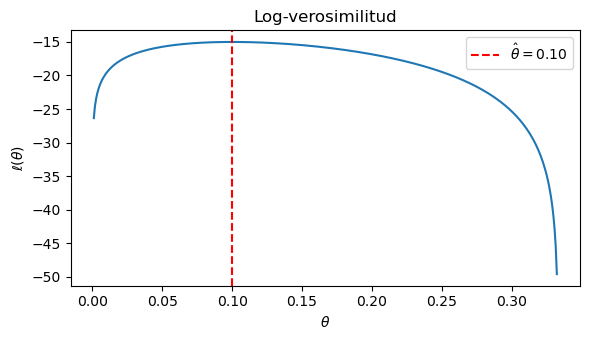

In [38]:
# Comprobación del Punto 1
#
# Usando scipy.optimize encontramos el theta que maximiza la log-verosimilitud 

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

muestra = np.array([2, 2, 0, 2, 0, 2, 3, 2, 3, 1])
n0, n1, n2, n3 = np.bincount(muestra, minlength=4)   # conteos por valor

def neg_log_verosimilitud(theta):
    # -log L(theta); pmf del modelo: [theta, 2theta, (1-3theta)/3, 2(1-3theta)/3]
    p = np.array([theta, 2*theta, (1 - 3*theta)/3, 2*(1 - 3*theta)/3])
    return -(n0*np.log(p[0]) + n1*np.log(p[1]) + n2*np.log(p[2]) + n3*np.log(p[3]))

# Maximizar log L  <=>  minimizar -log L, en el dominio válido (0, 1/3)
res = minimize_scalar(neg_log_verosimilitud, bounds=(1e-6, 1/3 - 1e-6), method="bounded")
theta_opt = res.x

print(f"theta_hat (scipy.optimize)  = {theta_opt:.4f}")

# Gráfico: log-verosimilitud y el máximo hallado por el optimizador
th = np.linspace(1e-3, 1/3 - 1e-3, 400)
plt.figure(figsize=(6, 3.5))
plt.plot(th, -neg_log_verosimilitud(th))
plt.axvline(theta_opt, color="red", ls="--", label=fr"$\hat\theta = {theta_opt:.2f}$")
plt.xlabel(r"$\theta$"); plt.ylabel(r"$\ell(\theta)$")
plt.title("Log-verosimilitud"); plt.legend()
plt.tight_layout(); plt.show()


# Punto 2

**(3 puntos)** Se pretende estimar los valores de producción $Y$ (en miles de toneladas) de cierto material, en función del tiempo transcurrido $X$ (en meses) usando los valores de la tabla:

| $X$ | $Y$ |
|:---:|:---:|
| $0$ | $0$ |
| $7$ | $60$ |
| $11$ | $135$ |
| $15$ | $213$ |
| $22$ | $574$ |

Se plantea un modelo de la forma $Y = a + bx + cx^2$. Encontrar los estimadores de mínimos cuadrados para $a$, $b$ y $c$ en este modelo.

## Respuesta al punto 2

> **Respuesta:** $\hat a \approx 7.9743$, $\hat b \approx -4.5075$, $\hat c \approx 1.3539$, es decir $\hat Y = 7.9743 - 4.5075\,x + 1.3539\,x^{2}$.

### Principio de mínimos cuadrados

El apunte plantea la regresión como la búsqueda de una función que minimiza el error cuadrático medio; para el modelo lineal simple $h(x)=\beta_0+\beta_1 x$ esto conduce a $\beta_1=\mathrm{Cov}(X,Y)/\mathrm{Var}(X)$. Acá el modelo es **cuadrático**,

$$
Y=a+bx+cx^{2},
$$

así que aplicamos el mismo principio pero a tres parámetros: buscamos $(a,b,c)$ que minimicen la suma de los cuadrados de los residuos sobre los 5 datos:

$$
S(a,b,c)=\sum_{i=1}^{5}\bigl(y_i-a-b x_i-c x_i^{2}\bigr)^{2}.
$$

### Condiciones de primer orden $\to$ ecuaciones normales

En el mínimo, las tres derivadas parciales se anulan:

$$
\frac{\partial S}{\partial a}=-2\sum_i \bigl(y_i-a-bx_i-cx_i^{2}\bigr)=0,
$$
$$
\frac{\partial S}{\partial b}=-2\sum_i x_i\bigl(y_i-a-bx_i-cx_i^{2}\bigr)=0,
$$
$$
\frac{\partial S}{\partial c}=-2\sum_i x_i^{2}\bigl(y_i-a-bx_i-cx_i^{2}\bigr)=0.
$$

Reordenando cada una (pasando los términos con $a,b,c$ a la izquierda) se obtienen las **ecuaciones normales**:

$$
\begin{aligned}
n\,a + \Bigl(\textstyle\sum x_i\Bigr) b + \Bigl(\textstyle\sum x_i^{2}\Bigr) c &= \textstyle\sum y_i,\\[2pt]
\Bigl(\textstyle\sum x_i\Bigr) a + \Bigl(\textstyle\sum x_i^{2}\Bigr) b + \Bigl(\textstyle\sum x_i^{3}\Bigr) c &= \textstyle\sum x_i y_i,\\[2pt]
\Bigl(\textstyle\sum x_i^{2}\Bigr) a + \Bigl(\textstyle\sum x_i^{3}\Bigr) b + \Bigl(\textstyle\sum x_i^{4}\Bigr) c &= \textstyle\sum x_i^{2} y_i.
\end{aligned}
$$

### Cálculo de las sumas

| $x_i$ | $y_i$ | $x_i^2$ | $x_i^3$ | $x_i^4$ | $x_i y_i$ | $x_i^2 y_i$ |
|--:|--:|--:|--:|--:|--:|--:|
| 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| 7 | 60 | 49 | 343 | 2401 | 420 | 2940 |
| 11 | 135 | 121 | 1331 | 14641 | 1485 | 16335 |
| 15 | 213 | 225 | 3375 | 50625 | 3195 | 47925 |
| 22 | 574 | 484 | 10648 | 234256 | 12628 | 277816 |
| $\sum$ | **982** | **879** | **15697** | **301923** | **17728** | **345016** |

Con $n=5$:

$$
\sum x_i=55,\quad \sum x_i^{2}=879,\quad \sum x_i^{3}=15697,\quad \sum x_i^{4}=301923,
$$
$$
\sum y_i=982,\quad \sum x_i y_i=17728,\quad \sum x_i^{2} y_i=345016.
$$

### Sistema de ecuaciones normales

$$
\begin{aligned}
(1)\quad & 5a + 55b + 879c = 982,\\
(2)\quad & 55a + 879b + 15697c = 17728,\\
(3)\quad & 879a + 15697b + 301923c = 345016.
\end{aligned}
$$

### Resolución por eliminación

**Eliminamos $a$.** Como $55/5=11$, hacemos $(2)-11\,(1)$:

$$
274b + 6028c = 6926. \tag{4}
$$

Para la tercera, $5\,(3)-879\,(1)$ cancela el término en $a$:

$$
30140b + 736974c = 861902. \tag{5}
$$

**Eliminamos $b$.** Como $30140/274=110$, hacemos $(5)-110\,(4)$:

$$
73894\,c = 100042 \;\Longrightarrow\; c=\frac{100042}{73894}\approx 1.3539.
$$

**Sustitución hacia atrás.** De $(4)$:

$$
274b = 6926 - 6028c \approx 6926 - 8161.06 = -1235.06 \;\Longrightarrow\; b\approx -4.5075.
$$

De $(1)$:

$$
5a = 982 - 55b - 879c \approx 982 + 247.91 - 1190.04 = 39.87 \;\Longrightarrow\; a\approx 7.9743.
$$

### Resultado

$$
\boxed{\;\hat a \approx 7.9743,\qquad \hat b \approx -4.5075,\qquad \hat c \approx 1.3539\;}
$$

es decir, el modelo ajustado por mínimos cuadrados es

$$
\hat Y = 7.9743 - 4.5075\,x + 1.3539\,x^{2}.
$$


a = 7.9743
b = -4.5075
c = 1.3539

Modelo ajustado:  Y = 7.9743 + (-4.5075)*x + 1.3539*x^2


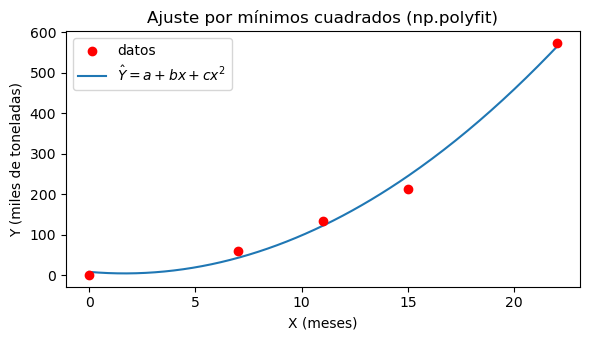

In [39]:
# Comprobación del Punto 2
#
# Verificamos los coeficientes con el ajuste por mínimos cuadrados de numpy (np.polyfit)

import numpy as np
import matplotlib.pyplot as plt

x = np.array([0, 7, 11, 15, 22], dtype=float)
y = np.array([0, 60, 135, 213, 574], dtype=float)

# np.polyfit hace directamente el ajuste por mínimos cuadrados de grado 2.
# Devuelve los coeficientes de MAYOR a menor grado: [c, b, a].
c, b, a = np.polyfit(x, y, 2)
print(f"a = {a:.4f}")
print(f"b = {b:.4f}")
print(f"c = {c:.4f}")
print(f"\nModelo ajustado:  Y = {a:.4f} + ({b:.4f})*x + {c:.4f}*x^2")

# Gráfico del ajuste
xx = np.linspace(0, 22, 200)
yy = a + b*xx + c*xx**2
plt.figure(figsize=(6, 3.5))
plt.scatter(x, y, color="red", zorder=3, label="datos")
plt.plot(xx, yy, label=r"$\hat Y = a + bx + cx^2$")
plt.xlabel("X (meses)"); plt.ylabel("Y (miles de toneladas)")
plt.title("Ajuste por mínimos cuadrados (np.polyfit)"); plt.legend()
plt.tight_layout(); plt.show()


# Punto 3

**(4 puntos)** Don Francisco tiene 6 clientes a los que les ha vendido mercancías a crédito y, de ellos, 1 están en mora con el pago prometido. Matías, teniendo en cuenta la información disponible, considera que puede modelar el porcentaje $p$ de morosidad según una distribución $\mathcal{B}(1, 3)$. Para determinar los parámetros $\alpha$ y $\beta$, decide usar inferencia bayesiana. Con esto, pretende explicarle a Don Francisco cómo será el comportamiento de pago de sus clientes a crédito.

Determinen la distribución a posteriori del parámetro $p$ de porcentaje de morosidad ($\alpha$ y $\beta$). Determinar su media y su varianza.

## Respuesta al punto 3

> **Respuesta:** la distribución a posteriori es $p \mid \text{datos} \sim \mathcal{B}(2,\,8)$, con media $\mathbb{E}[p]=\dfrac{2}{10}=0.2$ y varianza $\mathrm{Var}[p]=\dfrac{16}{1100}\approx 0.01455$.

### Planteo bayesiano

Sea $p$ el porcentaje (probabilidad) de morosidad. Tenemos:

- **Datos:** $n=6$ clientes, de los cuales $k=1$ está en mora. Modelamos la cantidad de morosos como una $\mathrm{Binomial}(n=6,\,p)$.
- **A priori:** Matías cree que $p\sim \mathcal{B}(\alpha_0,\beta_0)$ con $\alpha_0=1,\ \beta_0=3$, es decir una distribución **Beta**.

El diagrama de distribuciones conjugadas del apunte indica que la **Beta es conjugada de la Binomial** (a través del parámetro $p$): si la a priori es Beta, la a posteriori también será Beta.

### Densidades

A priori, $\mathcal{B}(1,3)$:

$$
\pi(p)=\frac{p^{\alpha_0-1}(1-p)^{\beta_0-1}}{B(\alpha_0,\beta_0)}
=\frac{p^{0}(1-p)^{2}}{B(1,3)},\qquad 0<p<1,
$$

con $B(1,3)=\dfrac{\Gamma(1)\Gamma(3)}{\Gamma(4)}=\dfrac{1\cdot 2}{6}=\dfrac13$, de modo que $\pi(p)=3(1-p)^{2}$.

Verosimilitud (1 moroso en 6):

$$
f_{X\mid\Theta=p}(\bar x)=\binom{6}{1}p^{1}(1-p)^{5}=6\,p\,(1-p)^{5}.
$$

### A posteriori vía teorema de Bayes

Usamos la fórmula del apunte:

$$
f_{\Theta\mid X=\bar x}(p)=\frac{f_{X\mid\Theta=p}(\bar x)\,\pi(p)}{\displaystyle\int_0^1 f_{X\mid\Theta=p}(\bar x)\,\pi(p)\,dp}.
$$

El numerador, juntando potencias y dejando de lado las constantes (que se reabsorben al normalizar), es proporcional a:

$$
f_{\Theta\mid X=\bar x}(p)\;\propto\; \underbrace{p^{k}(1-p)^{n-k}}_{\text{verosimilitud}}\cdot \underbrace{p^{\alpha_0-1}(1-p)^{\beta_0-1}}_{\text{a priori}}
= p^{\,k+\alpha_0-1}(1-p)^{\,n-k+\beta_0-1}.
$$

Reemplazando $k=1,\ n=6,\ \alpha_0=1,\ \beta_0=3$:

$$
f_{\Theta\mid X=\bar x}(p)\;\propto\; p^{\,1}(1-p)^{\,7}.
$$

Este es exactamente el núcleo de una **Beta** con parámetros

$$
\boxed{\;\alpha=\alpha_0+k=1+1=2,\qquad \beta=\beta_0+(n-k)=3+5=8\;}
$$

(la constante de normalización debe ser $1/B(2,8)$). Es la regla de actualización conjugada Beta–Binomial:

$$
\mathcal{B}(\alpha_0,\beta_0)\;\xrightarrow{\;k\text{ éxitos en }n\;}\;\mathcal{B}\bigl(\alpha_0+k,\ \beta_0+n-k\bigr).
$$

La distribución a posteriori es entonces $\;p\mid \text{datos}\sim\mathcal{B}(2,8)$.

### Media y varianza

Con las fórmulas de la distribución Beta:

$$
\mathbb{E}[p\mid\text{datos}]=\frac{\alpha}{\alpha+\beta}=\frac{2}{2+8}=\frac{2}{10}=0.2,
$$

$$
\mathrm{Var}[p\mid\text{datos}]=\frac{\alpha\beta}{(\alpha+\beta)^{2}(\alpha+\beta+1)}=\frac{2\cdot 8}{10^{2}\cdot 11}=\frac{16}{1100}=\frac{4}{275}\approx 0.01455.
$$

### Interpretación

La media a priori era $\alpha_0/(\alpha_0+\beta_0)=1/4=0.25$ y la proporción observada en los datos es $1/6\approx 0.167$. La media a posteriori, $0.2$, queda **entre ambas**: la creencia inicial se corrige hacia abajo al incorporar la evidencia (sólo 1 moroso de 6), que es justo lo que esperamos del proceso de inferencia bayesiana.


Prior Beta(1,3)  ->  Posterior Beta(2,8)
Media    = 0.200000
Varianza = 0.014545   (= 16/1100)


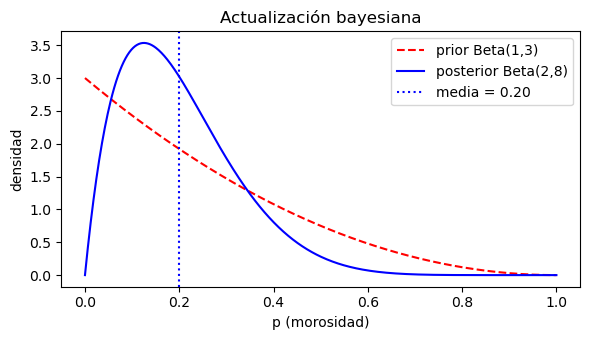

In [ ]:
# Comprobación del Punto 3
#
# Actualización conjugada Beta-Binomial. scipy.stats.beta da media y varianza directo.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Datos y prior
n_clientes, morosos = 6, 1
alpha_prior, beta_prior = 1, 3

# Posterior conjugada: alpha + éxitos (morosos), beta + fracasos (no morosos)
alpha_post = alpha_prior + morosos
beta_post  = beta_prior + (n_clientes - morosos)
print(f"Prior Beta({alpha_prior},{beta_prior})  ->  Posterior Beta({alpha_post},{beta_post})")

# Media y varianza
media, var = beta.stats(alpha_post, beta_post, moments="mv")
print(f"Media    = {float(media):.6f}")
print(f"Varianza = {float(var):.6f}   (= 16/1100)")

# Gráfico: prior vs posterior
x = np.linspace(0, 1, 500)
plt.figure(figsize=(6, 3.5))
plt.plot(x, beta.pdf(x, alpha_prior, beta_prior), "r--", label=f"prior Beta({alpha_prior},{beta_prior})")
plt.plot(x, beta.pdf(x, alpha_post, beta_post), "b-", label=f"posterior Beta({alpha_post},{beta_post})")
plt.axvline(float(media), color="blue", ls=":", label=f"media = {float(media):.2f}")
plt.xlabel("p (morosidad)"); plt.ylabel("densidad")
plt.title("Actualización bayesiana"); plt.legend(); plt.tight_layout(); plt.show()
